In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler
from linearmodels.panel import PanelOLS
import matplotlib.pyplot as plt


In [2]:
os.chdir("C:/Users/fabia/Documents/#Köln/Uni/Semester 3/SusDev/DietOnEmissions")
df = pd.read_csv("data/training_full_dataset.csv")
df = df.set_index(["iso3c", "Year"])


Median ASF share over all years: 0.1843394002121122
Median ADF share 2023: 0.1869794122412245


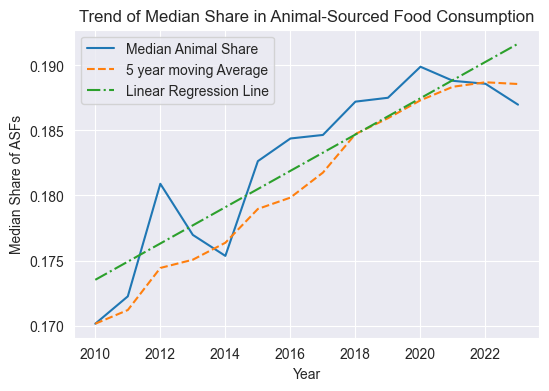

In [3]:
median_animal_share = df.groupby("iso3c")["animal_share"].mean().median()
median_animal_share_per_year = df.groupby("Year")["animal_share"].median()
print(f"Median ASF share over all years: {median_animal_share}")
print(f"Median ADF share 2023: {median_animal_share_per_year[2023]}")

x = median_animal_share_per_year.index
y = median_animal_share_per_year.values
moving_avg = median_animal_share_per_year.rolling(window=4, min_periods=1).mean()
regression_y = np.poly1d(np.polyfit(x, y, deg=1))(x)

plt.figure(figsize=(6, 4))
plt.plot(x, y, label="Median Animal Share")
plt.plot(x, moving_avg, linestyle="--", label="5 year moving Average")
plt.plot(x, regression_y, linestyle="-.", label="Linear Regression Line")
plt.xlabel("Year")
plt.ylabel("Median Share of ASFs")
plt.title("Trend of Median Share in Animal-Sourced Food Consumption")
plt.grid(True)
plt.legend()
plt.savefig("plots/median_animal_share_per_year.pdf", format="pdf", bbox_inches="tight")
plt.show()
    

In [4]:
target = "animal_share"

df["log_gdp_pc"] = np.log(df["gdp_pc_ppp"])
df["log_pop"] = np.log(df["Population"])
predictors = [
    "log_gdp_pc",
    "asf_price_index",
    "psf_price_index",
    "young_share",
    "urban_pop_share",
    "arable_land_km2",
    "Population",
    "access_electricity",
    "trade_openness"
]
not_selected = [    
    "gdp_pc_ppp", # Use log
    "kcalpppd", # insignificance
    "work_share",
    "internet_users",
    "secondary_enrol",  # Not selected due to too many missing values
    "poverty_215",
    "poverty_685",
    "food_insec_modsev",
    "gini_coeficient",
    "protected_area_km2",
    "emissions",
    "religion", # Categorical Variables
    "climate_zone",
    "food_price_index", # Time fixed and also removed now
    "meat_price_index",
    "cereals_price_index",
    "average_temp", # Country fixed
    "was_colonized",
    "landlocked",
    "asf_price",
    "psf_price",
    "land_area_km2"
]

df_model = df[[target] + predictors].dropna()


In [5]:
scaler = StandardScaler()
df_scaled = df_model.copy()
df_scaled[predictors] = scaler.fit_transform(df_model[predictors])


In [6]:
# Add constant for PanelOLS
df_scaled = df_scaled.assign(const=1)

model = PanelOLS(
    df_scaled[target],
    df_scaled[predictors + ["const"]],
    entity_effects=True,   # country fixed effects
    time_effects=True      # year fixed effects
)

results = model.fit(cov_type="clustered", cluster_entity=True)
print(results)


                          PanelOLS Estimation Summary                           
Dep. Variable:           animal_share   R-squared:                        0.1472
Estimator:                   PanelOLS   R-squared (Between):             -0.0068
No. Observations:                1486   R-squared (Within):               0.1343
Date:                Fri, Dec 26 2025   R-squared (Overall):             -0.0070
Time:                        16:00:12   Log-likelihood                    4353.7
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      25.952
Entities:                         111   P-value                           0.0000
Avg Obs:                       13.387   Distribution:                  F(9,1353)
Min Obs:                       1.0000                                           
Max Obs:                       14.000   F-statistic (robust):             6.0111
                            

In [7]:
latex_table = results.summary.as_latex()
with open("Latex/Tables/regression_results_full.tex", "w") as f:
    f.write(latex_table)
    

In [11]:
# Log transformations
df_model2 = df_model.assign(const=1)
df_model2["log_pop"] = np.log(df_model2["Population"])
df_model2["log_asf_price"] = np.log(df_model2["asf_price_index"])
df_model2["log_psf_price"] = np.log(df_model2["psf_price_index"])
df_model2["log_rel_price"] = (
    df_model2["log_asf_price"] - df_model2["log_psf_price"]
)
df_model2["log_rel_price_x_log_gdp"] = (
    df_model2["log_rel_price"] / df_model2["log_gdp_pc"]
)

predictors_log = [
    "log_gdp_pc",
    "log_rel_price",
    "log_rel_price_x_log_gdp",
    "young_share",
    "urban_pop_share",
    "arable_land_km2",
    "log_pop"
]

model2 = PanelOLS(
    df_model2[target],
    df_model2[predictors_log + ["const"]],
    entity_effects=True,   # country fixed effects
    time_effects=True      # year fixed effects
)

results2 = model2.fit(cov_type="clustered", cluster_entity=True)
print(results2)


                          PanelOLS Estimation Summary                           
Dep. Variable:           animal_share   R-squared:                        0.1349
Estimator:                   PanelOLS   R-squared (Between):              0.1666
No. Observations:                1486   R-squared (Within):               0.0552
Date:                Thu, Dec 18 2025   R-squared (Overall):              0.1788
Time:                        11:10:39   Log-likelihood                    4343.1
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      30.193
Entities:                         111   P-value                           0.0000
Avg Obs:                       13.387   Distribution:                  F(7,1355)
Min Obs:                       1.0000                                           
Max Obs:                       14.000   F-statistic (robust):             3.5944
                            

In [12]:
latex_table = results2.summary.as_latex()
with open("Latex/Tables/regression_results_log_full.tex", "w") as f:
    f.write(latex_table)
    

In [7]:
# Log transformations
df_model3 = df_model.assign(const=1)
df_model3["log_asf_price"] = np.log(df_model3["asf_price_index"])
df_model3["log_psf_price"] = np.log(df_model3["psf_price_index"])
df_model3["log_rel_price"] = (
    df_model3["log_asf_price"] - df_model3["log_psf_price"]
)
df_model3["log_rel_price_x_log_gdp"] = (
    df_model3["log_rel_price"] / df_model3["log_gdp_pc"]
)

predictors_log = [
    "log_gdp_pc",
    "log_rel_price",
    "log_rel_price_x_log_gdp",
    "young_share",
    "urban_pop_share",
    "arable_land_km2",
    "Population"
]

model3 = PanelOLS(
    df_model3[target],
    df_model3[predictors_log + ["const"]],
    entity_effects=True,   # country fixed effects
    time_effects=True      # year fixed effects
)

results3 = model3.fit(cov_type="clustered", cluster_entity=True)
print(results3)


                          PanelOLS Estimation Summary                           
Dep. Variable:           animal_share   R-squared:                        0.1365
Estimator:                   PanelOLS   R-squared (Between):             -0.0707
No. Observations:                1486   R-squared (Within):               0.0790
Date:                Thu, Dec 18 2025   R-squared (Overall):             -0.0658
Time:                        11:05:41   Log-likelihood                    4344.4
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      30.587
Entities:                         111   P-value                           0.0000
Avg Obs:                       13.387   Distribution:                  F(7,1355)
Min Obs:                       1.0000                                           
Max Obs:                       14.000   F-statistic (robust):             6.6800
                            